In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
import numpy as np

import scipy
import scipy.cluster.hierarchy as hac
from scipy.cluster.hierarchy import dendrogram, linkage

from matplotlib import pyplot as plt

import fastcluster as fc

In [2]:
#Make data
def make_metadata(matrix):
    data = pd.read_table(matrix, sep = ',', header = 0)
    data = pd.DataFrame(data, columns=['orig.ident', 'SingleR.calls', 'Phase']).dropna()
    return data

In [3]:
#Sunburst
def make_sunburst(data):
    fig = px.sunburst(data, path=data.columns, color='SingleR.calls', 
                      branchvalues='total',template='ggplot2',title='Sunburst Metadata',
                      color_discrete_sequence=px.colors.qualitative.Pastel)

    fig.update_traces(textinfo='label+percent entry')
    fig.update_layout(margin=dict(t=50,l=0,r=0,b=50))
    
    return fig

In [7]:
data = make_metadata('/home/boris/Documents/analyse/metadata_matrix_FL140304.csv')
a = make_sunburst(data)
a.write_image('/home/boris/Documents/analyse/sunburst.png')
a.write_html("/home/boris/Documents/analyse/sunburst.html")
#data = pd.read_table('metadata_matrix_FL12C1888.csv', sep = ',', header = 0)
#data


In [10]:
data = pd.read_csv('metadata_matrix_FL12C1888.csv', sep = ',', header = 0)
data = pd.DataFrame(data.T.iloc[1:].T.values, columns=data.columns[1:], index = data.T.iloc[0])
data

,orig.ident,nCount_RNA,nFeature_RNA,nCount_HTO,nFeature_HTO,HTO_maxID,HTO_secondID,HTO_margin,HTO_classification,HTO_classification.global,...,c_gene,cdr3,cdr3s_aa,percent.mt,S.Score,G2M.Score,Phase,old.ident,RNA_snn_res.0.5,seurat_clusters
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
AAACCTGAGGGAGTAA-1,hFL_180008B,1865,913,206,2,collagenase,subtilisin,3.26459,collagenase,Singlet,...,IGHG1,CATSTLHTKGAYGNTWHGPFTKW,IGH:CATSTLHTKGAYGNTWHGPFTKW;IGK:CQLSDTSLQYTF,2.25201,-0.0379119,-0.0435219,G1,0,0,0
AAACCTGCATGGTAGG-1,hFL_180008B,2672,1124,202,3,actinomycin-D,subtilisin,4.16199,actinomycin-D,Singlet,...,IGKC,CQLSDTSLQYTF,IGK:CQLSDTSLQYTF,1.72156,-0.0408055,-0.0819521,G1,0,0,0
AAACCTGGTTTCGCTC-1,hFL_180008B,4534,1726,135,1,collagenase,pregreffe,3.55914,collagenase,Singlet,...,NaN,NaN,NaN,2.42611,0.0335178,-0.0174821,S,0,0,0
AAACGGGTCAGTTAGC-1,hFL_180008B,1232,930,183,2,actinomycin-D,subtilisin,4.07386,actinomycin-D,Singlet,...,NaN,NaN,NaN,0,0.0796085,-0.113805,S,1,1,1
AAACGGGTCGATAGAA-1,hFL_180008B,2616,1186,280,3,pregreffe,actinomycin-D,2.72602,pregreffe,Singlet,...,NaN,NaN,NaN,2.67584,-0.0243725,-0.0262269,G1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGCGTCGTAAACACA-1,hFL_180008B,3831,1241,86,3,pregreffe,collagenase,1.74118,pregreffe,Singlet,...,IGKC,CQLSDTSLQYTF,IGK:CQLSDTSLQYTF,2.03602,0.0754297,0.0307931,S,1,1,1
TTTATGCTCCATTCTA-1,hFL_180008B,4662,1750,202,3,collagenase,subtilisin,3.72178,collagenase,Singlet,...,NaN,NaN,NaN,0.750751,-0.0653421,-0.0725692,G1,0,0,0
TTTGGTTCATCTGGTA-1,hFL_180008B,2390,881,368,1,pregreffe,subtilisin,3.32958,pregreffe,Singlet,...,NaN,NaN,NaN,1.96653,0.0579646,0.0307106,S,2,2,2


In [14]:
count = pd.read_csv('count_matrix_FL12C1888.csv', sep = ',', header = 0)
count = pd.DataFrame(count.T[1:].values, columns=count.T.iloc[0].values, index = count.T.iloc[1:].index)
count

,LINC01409,LINC01128,LINC00115,NOC2L,ISG15,C1orf159,TNFRSF18,TNFRSF4,SDF4,UBE2J2,...,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,AL592183.1,AC240274.1
AAACCTGAGGGAGTAA-1,-0.0901183,-0.185172,-0.145059,-0.325447,3.30038,-0.117672,-0.164699,-0.150965,-0.394527,-0.329371,...,0.0172903,-0.826614,0.268619,0.630714,0.0875787,-1.61641,-0.373259,1.01646,-0.108577,-0.0449921
AAACCTGCATGGTAGG-1,-0.0901183,-0.185172,-0.145059,-0.325447,-0.412608,-0.117672,-0.164699,-0.150965,-0.394527,-0.329371,...,0.665143,0.0359514,0.320249,-0.684399,0.370645,-0.0737429,-0.373259,0.300242,-0.108577,-0.0449921
AAACCTGGTTTCGCTC-1,-0.0901183,-0.185172,-0.145059,-0.325447,-0.412608,-0.117672,-0.164699,-0.150965,-0.394527,-0.329371,...,-0.143222,0.616531,0.681108,0.702535,0.264521,1.28301,-0.373259,0.72152,-0.108577,-0.0449921
AAACGGGTCAGTTAGC-1,-0.0901183,-0.185172,-0.145059,-0.325447,-0.412608,-0.117672,-0.164699,-0.150965,-0.394527,-0.329371,...,-1.81745,-2.56071,-3.3905,-3.05333,-1.73124,-1.61641,-0.373259,-2.74534,-0.108577,-0.0449921
AAACGGGTCGATAGAA-1,-0.0901183,6.07871,-0.145059,-0.325447,-0.412608,-0.117672,-0.164699,-0.150965,-0.394527,-0.329371,...,0.321385,0.554046,-0.422975,0.62867,-1.73124,-0.0571407,-0.373259,0.587387,-0.108577,-0.0449921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGCGTCGTAAACACA-1,-0.0901183,-0.185172,-0.145059,-0.325447,-0.412608,-0.117672,-0.164699,-0.150965,-0.394527,-0.329371,...,-0.54448,0.212082,-1.24072,0.70406,-0.469317,-1.61641,-0.373259,-0.0298639,-0.108577,-0.0449921
TTTATGCTCCATTCTA-1,-0.0901183,-0.185172,-0.145059,-0.325447,2.93012,-0.117672,-0.164699,-0.150965,-0.394527,-0.329371,...,-0.68129,-1.48687,-0.495226,-0.549933,-0.604939,-0.480827,-0.373259,-0.808773,-0.108577,-0.0449921
TTTGGTTCATCTGGTA-1,-0.0901183,-0.185172,-0.145059,-0.325447,2.88954,-0.117672,-0.164699,-0.150965,-0.394527,-0.329371,...,1.03394,-0.117895,0.773151,-0.165642,-0.11367,0.0144906,-0.373259,0.547055,-0.108577,-0.0449921
TTTGTCACAAACCCAT-1,-0.0901183,-0.185172,-0.145059,-0.325447,-0.412608,-0.117672,-0.164699,-0.150965,-0.394527,-0.329371,...,1.02808,-1.02322,0.439046,-1.23584,0.462485,0.00948907,-0.373259,-2.74534,-0.108577,-0.0449921


In [78]:
sumo = pd.DataFrame(count.sum(axis=0), index = count.columns)
sumo = pd.DataFrame(sumo.sort_values(by=0).values, index = sumo.index)
sumo = pd.DataFrame(sumo.where(sumo.values.astype(float)<-12.1), index = sumo.index).dropna()

In [74]:
result = pd.concat([count,data],axis=1)

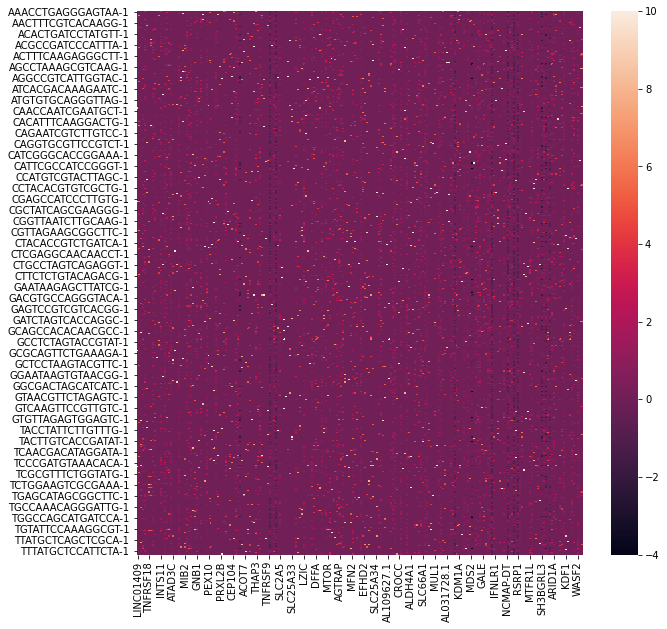

In [83]:
corr = pd.DataFrame(count, columns = sumo.index)

plt.figure(figsize=(10,10))
heatmap = sns.heatmap(corr.astype(int))
plt.show()

In [85]:
corr.astype(int)

,LINC01409,LINC01128,LINC00115,NOC2L,ISG15,C1orf159,TNFRSF18,TNFRSF4,SDF4,UBE2J2,...,NUDC,KDF1,SLC9A1,WDTC1,TMEM222,SYTL1,MAP3K6,WASF2,FGR,IFI6
AAACCTGAGGGAGTAA-1,0,0,0,0,3,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
AAACCTGCATGGTAGG-1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
AAACCTGGTTTCGCTC-1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
AAACGGGTCAGTTAGC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACGGGTCGATAGAA-1,0,6,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGCGTCGTAAACACA-1,0,0,0,0,0,0,0,0,0,0,...,1,10,0,0,0,0,0,1,0,0
TTTATGCTCCATTCTA-1,0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
TTTGGTTCATCTGGTA-1,0,0,0,0,2,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
TTTGTCACAAACCCAT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
